In [13]:
# Email Spam detection Assignment 2
# 1. Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [2]:
# 2. Load dataset
df = pd.read_csv('emails.csv')  # replace with your CSV path
print("Dataset preview:\n", df.head())


Dataset preview:
   Email No.  the  to  ect  and  for  of    a  you  hou  ...  connevey  jay  \
0   Email 1    0   0    1    0    0   0    2    0    0  ...         0    0   
1   Email 2    8  13   24    6    6   2  102    1   27  ...         0    0   
2   Email 3    0   0    1    0    0   0    8    0    0  ...         0    0   
3   Email 4    0   5   22    0    5   1   51    2   10  ...         0    0   
4   Email 5    7   6   17    1    5   2   57    0    9  ...         0    0   

   valued  lay  infrastructure  military  allowing  ff  dry  Prediction  
0       0    0               0         0         0   0    0           0  
1       0    0               0         0         0   1    0           0  
2       0    0               0         0         0   0    0           0  
3       0    0               0         0         0   0    0           0  
4       0    0               0         0         0   1    0           0  

[5 rows x 3002 columns]


In [3]:
# ---------------------------
# i) Data Preprocessing & Clearing
# ---------------------------

# Features and label
X = df.drop(['Email No.', 'Prediction'], axis=1)
y = df['Prediction'].map(lambda x: 1 if str(x).lower()=='spam' else 0)

print("Features shape:", X.shape)
print("Label distribution:\n", y.value_counts())


Features shape: (5172, 3000)
Label distribution:
 Prediction
0    5172
Name: count, dtype: int64


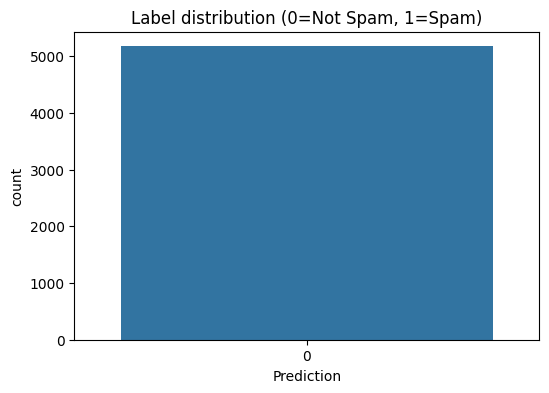

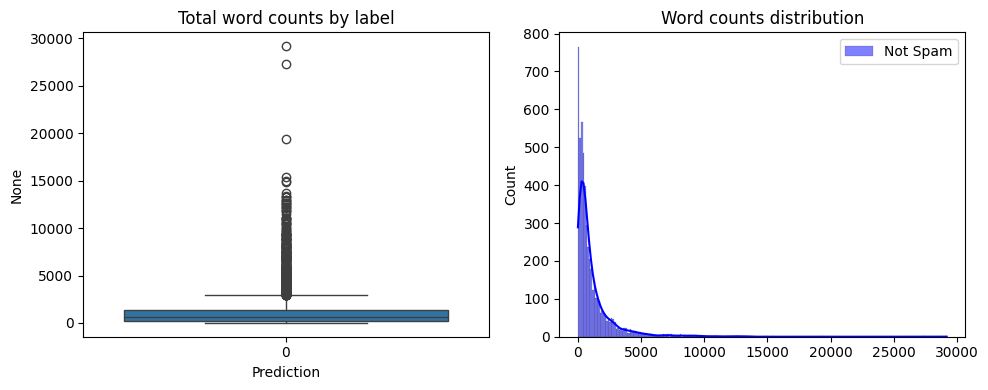

In [4]:
# ---------------------------
# ii) Exploratory Data Analysis
# ---------------------------

# Label distribution
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title('Label distribution (0=Not Spam, 1=Spam)')
plt.show()

# Word counts per email
email_word_counts = X.sum(axis=1)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(x=y, y=email_word_counts)
plt.title('Total word counts by label')
plt.subplot(1,2,2)
sns.histplot(email_word_counts[y==1], color='red', label='Spam', kde=True)
sns.histplot(email_word_counts[y==0], color='blue', label='Not Spam', kde=True)
plt.title('Word counts distribution')
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
# ---------------------------
# iii) Correlation
# ---------------------------

# Remove constant columns
X_nonconst = X.loc[:, (X != 0).any(axis=0)]
corr_with_label = X_nonconst.corrwith(y)
top_corr_features = corr_with_label.abs().sort_values(ascending=False).head(10)
print("Top features correlated with label:\n", top_corr_features)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Top features correlated with label:
 the   NaN
to    NaN
ect   NaN
and   NaN
for   NaN
of    NaN
a     NaN
you   NaN
hou   NaN
in    NaN
dtype: float64


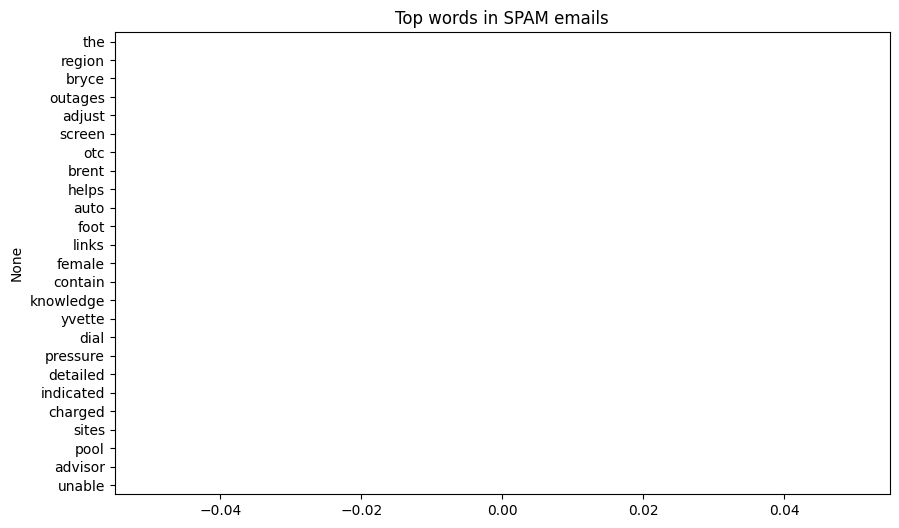

In [6]:
# ---------------------------
# iv) Graph of frequent words in spam email
# ---------------------------

spam_features = X[y==1].sum().sort_values(ascending=False).head(25)
plt.figure(figsize=(10,6))
sns.barplot(x=spam_features.values, y=spam_features.index)
plt.title('Top words in SPAM emails')
plt.show()

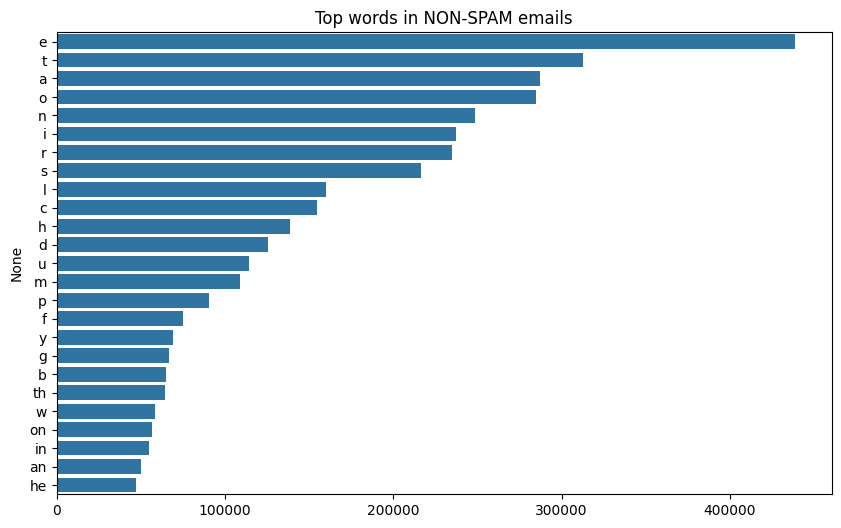

In [7]:
# ---------------------------
# v) Graph of frequent words in non-spam email
# ---------------------------

notspam_features = X[y==0].sum().sort_values(ascending=False).head(25)
plt.figure(figsize=(10,6))
sns.barplot(x=notspam_features.values, y=notspam_features.index)
plt.title('Top words in NON-SPAM emails')
plt.show()

Train labels:
 Prediction
0    2937
1    1200
Name: count, dtype: int64
Test labels:
 Prediction
0    735
1    300
Name: count, dtype: int64
Balanced train labels:
 Prediction
0    2937
1    2937
Name: count, dtype: int64
KNN Accuracy: 0.7382
              precision    recall  f1-score   support

           0     0.9915    0.6367    0.7755       735
           1     0.5258    0.9867    0.6860       300

    accuracy                         0.7382      1035
   macro avg     0.7586    0.8117    0.7307      1035
weighted avg     0.8565    0.7382    0.7495      1035

SVM Accuracy: 0.9671
              precision    recall  f1-score   support

           0     0.9782    0.9755    0.9768       735
           1     0.9404    0.9467    0.9435       300

    accuracy                         0.9671      1035
   macro avg     0.9593    0.9611    0.9602      1035
weighted avg     0.9672    0.9671    0.9672      1035

NaiveBayes Accuracy: 0.9536
              precision    recall  f1-score   support


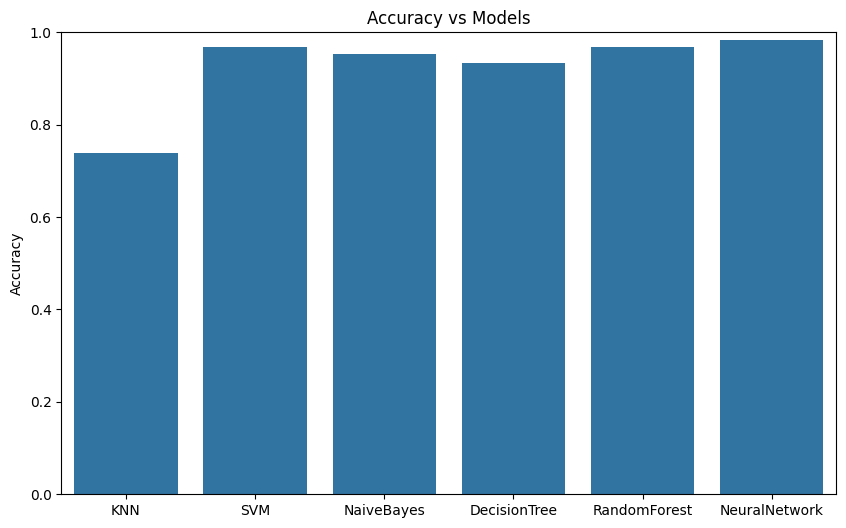

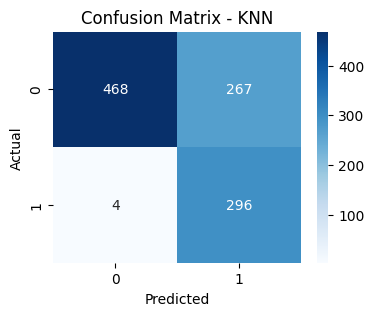

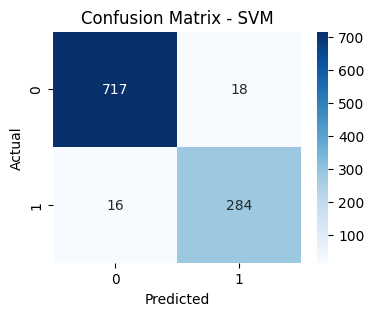

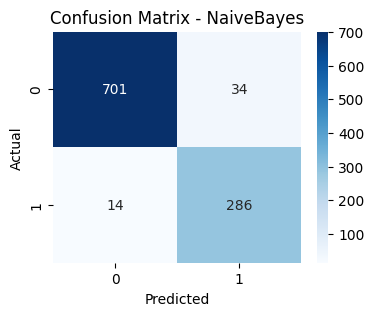

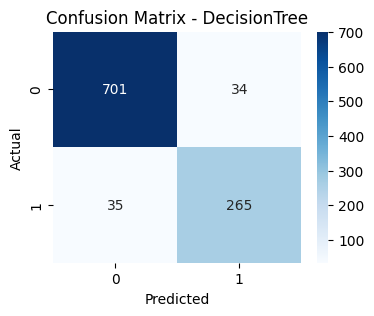

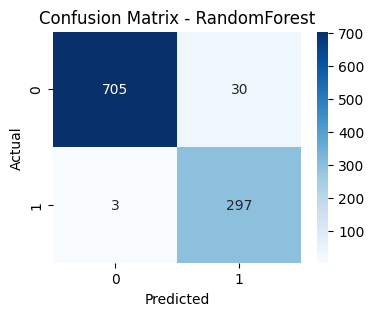

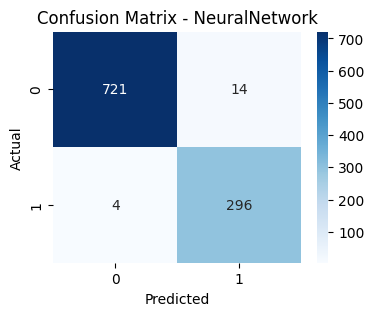

In [12]:
# ---------------------------
# vi) Classification & Accuracy vs Models
# ---------------------------

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Train-test split (stratified to keep class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train labels:\n", y_train.value_counts())
print("Test labels:\n", y_test.value_counts())

# 2. Apply SMOTE only on training set
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Balanced train labels:\n", y_train_bal.value_counts())

# 3. Define classifiers
models = {
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(kernel='linear', probability=True),
    'NaiveBayes': MultinomialNB(),
    'DecisionTree': DecisionTreeClassifier(),
    'RandomForest': RandomForestClassifier(),
    'NeuralNetwork': MLPClassifier(hidden_layer_sizes=(100,), max_iter=300)
}

# 4. Train & evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f'{name} Accuracy: {acc:.4f}')
    print(classification_report(y_test, y_pred, digits=4))

# 5. Accuracy vs Models
plt.figure(figsize=(10,6))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.ylim(0,1)
plt.title('Accuracy vs Models')
plt.ylabel('Accuracy')
plt.show()

# 6. Confusion matrices
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
